- Goal: To conduct a machine learnig to identify the best window that count churn customers

- Data information and meaning: The dataset comes from Olist, a Brazilian marketplace enabler that makes small and medium size merchants sell products in their platforms. They provided buyers information in their platform between the years 2016, and 2018. These data contain the decription of the customer delivery location, as well as order detail, and payment details.

- What are the data sorts (numerical, categorical, textual content, etc.) ?: We have numerical, categorical, and textual(review text) data.


Is there any known information on first-class troubles or obstacles?: An obstacle would be some nans and 

In [148]:
import pandas as pd
import numpy as np


In [149]:
# Load the Olist dataset

OLIST_PATH = "../Data/olist_dataset.csv"

olist_df = pd.read_csv(OLIST_PATH)

In [150]:
olist_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1141.0,1.0,8683.0,54.0,64.0,31.0,8577.0,itaquaquecetuba,SP,office_furniture
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1002.0,3.0,10150.0,89.0,15.0,40.0,88303.0,itajai,SC,housewares
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,955.0,1.0,8267.0,52.0,52.0,17.0,8577.0,itaquaquecetuba,SP,office_furniture
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1066.0,1.0,12160.0,56.0,51.0,28.0,8577.0,itaquaquecetuba,SP,office_furniture
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,407.0,1.0,5200.0,45.0,15.0,35.0,14940.0,ibitinga,SP,home_confort


In [151]:
olist_df.shape

(119143, 40)

In [152]:
olist_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    119143 non-null  str    
 1   customer_unique_id             119143 non-null  str    
 2   customer_zip_code_prefix       119143 non-null  int64  
 3   customer_city                  119143 non-null  str    
 4   customer_state                 119143 non-null  str    
 5   order_id                       119143 non-null  str    
 6   order_status                   119143 non-null  str    
 7   order_purchase_timestamp       119143 non-null  str    
 8   order_approved_at              118966 non-null  str    
 9   order_delivered_carrier_date   117057 non-null  str    
 10  order_delivered_customer_date  115722 non-null  str    
 11  order_estimated_delivery_date  119143 non-null  str    
 12  order_item_id                  118310 non

In [153]:
olist_df.dtypes.value_counts()

str        24
float64    15
int64       1
Name: count, dtype: int64

In [154]:
olist_df.nunique()

customer_id                      99441
customer_unique_id               96096
customer_zip_code_prefix         14994
customer_city                     4119
customer_state                      27
order_id                         99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
order_item_id                       21
product_id                       32951
seller_id                         3095
shipping_limit_date              93318
price                             5968
freight_value                     6999
payment_sequential                  29
payment_type                         5
payment_installments                24
payment_value                    29077
review_id                        98410
review_score                         5
review_comment_title              4527
review_comment_message   

In [155]:

in_list = ["price",	"freight_value", "payment_value", "payment_sequential", "payment_installments", "product_name_lenght", "product_description_lenght",	"product_photos_qty", "product_weight_g", "product_length_cm", "product_height_cm",	"product_width_cm"]

olist_df[in_list].describe()

,price,freight_value,payment_value,payment_sequential,payment_installments,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,118310.000000,118310.000000,119140.000000,119140.000000,119140.000000,116601.000000,116601.000000,116601.000000,118290.000000,118290.000000,118290.000000,118290.000000
mean,120.646603,20.032387,172.735135,1.094737,2.941246,48.767498,785.967822,2.205161,2112.250740,30.265145,16.619706,23.074799
std,184.109691,15.836850,267.776077,0.730141,2.777848,10.033540,652.584121,1.717452,3786.695111,16.189367,13.453584,11.749139
min,0.850000,0.000000,0.000000,1.000000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,39.900000,13.080000,60.850000,1.000000,1.000000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,74.900000,16.280000,108.160000,1.000000,2.000000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,134.900000,21.180000,189.240000,1.000000,4.000000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,6735.000000,409.680000,13664.080000,29.000000,24.000000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [156]:
olist_df.isnull().sum()

customer_id                           0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_id                              0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
payment_sequential                    3
payment_type                          3
payment_installments                  3
payment_value                         3
review_id                           997
review_score                        997
review_comment_title             105154


In [157]:
olist_df["product_name_lenght"].isnull().sum()

np.int64(2542)

In [158]:
olist_df["order_status"].value_counts()

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

In [159]:
cancelled_orders = olist_df.loc[
    olist_df["order_approved_at"].isnull(), 
    ["order_status", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_item_id", "product_id", "seller_id", "order_estimated_delivery_date"]
]

cancelled_orders

,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_item_id,product_id,seller_id,order_estimated_delivery_date
1263,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2018-10-10 00:00:00
1278,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2018-10-01 00:00:00
1948,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-29 00:00:00
3859,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-20 00:00:00
4506,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2018-09-10 00:00:00
...,...,...,...,...,...,...,...,...
113540,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2017-03-09 00:00:00
114420,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2017-09-12 00:00:00
114494,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2017-07-05 00:00:00
116661,canceled,NaN,NaN,NaN,NaN,NaN,NaN,2017-05-23 00:00:00


In [160]:
not_cancelled_orders = olist_df.loc[
    olist_df["order_status"]!= "canceled", 
    ["order_status", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"]
]

"NaN"in not_cancelled_orders["order_delivered_customer_date"]

False

In [161]:
print("NaN"in not_cancelled_orders["order_approved_at"])

print("NaN"in not_cancelled_orders["order_delivered_carrier_date"])

print("NaN"in not_cancelled_orders["order_delivered_customer_date"])

False
False
False


Dates are NaN where the order status is cancelled

In [162]:
len(cancelled_orders["order_status"])

177

Data characteristics

Price distribution

In [163]:

"price",	"freight_value", "payment_value"

('price', 'freight_value', 'payment_value')

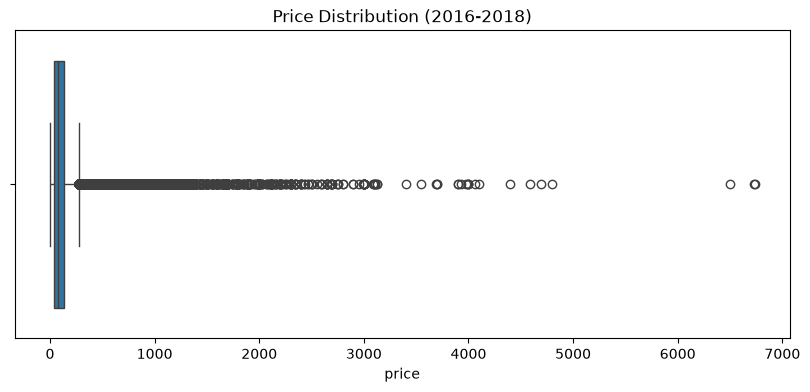

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (10,4))
sns.boxplot(data= olist_df, x = "price")


plt.title("Price Distribution (2016-2018)")
plt.xlabel("price")


plt.show()

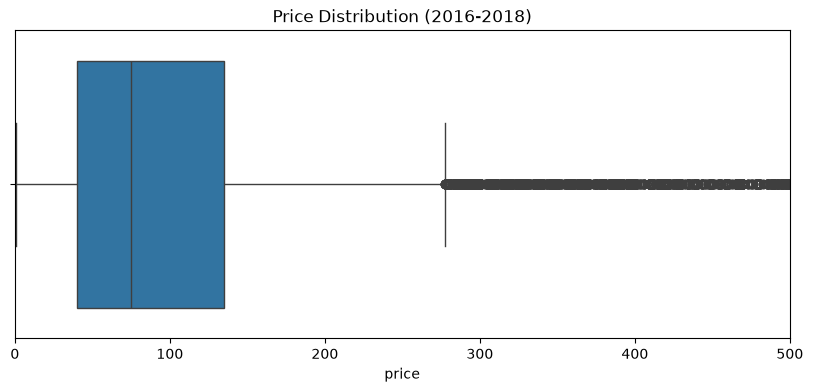

In [165]:
plt.figure(figsize= (10,4))
sns.boxplot(data= olist_df, x = "price")

plt.xlim((0,500))
plt.title("Price Distribution (2016-2018)")
plt.xlabel("price")


plt.show()

Freight ratio

In [166]:
olist_df["freight_ratio"] = olist_df["freight_value"]/olist_df["price"]


olist_df["freight_ratio"]

0         0.175054
1         0.160830
2         0.127126
3         0.155796
4         0.096739
            ...   
119138    0.185314
119139    0.123238
119140    0.514595
119141    0.032032
119142    0.556112
Name: freight_ratio, Length: 119143, dtype: float64

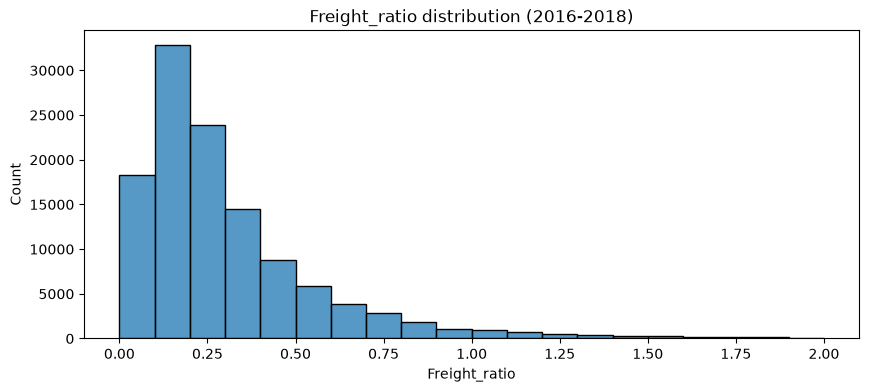

In [167]:
plt.figure(figsize= (10,4))
sns.histplot(data = olist_df, x = "freight_ratio", binwidth= 0.1, binrange= (0,2))


plt.title("Freight_ratio distribution (2016-2018)")
plt.xlabel("Freight_ratio")

plt.show()

Purchases per order

In [168]:
olist_date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_estimated_delivery_date", "shipping_limit_date", "order_delivered_customer_date"]

for col in olist_date_cols:
    olist_df[col] = pd.to_datetime(olist_df[col]).dt.date

print(olist_df[olist_date_cols].dtypes)

order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_estimated_delivery_date    object
shipping_limit_date              object
order_delivered_customer_date    object
dtype: object


In [169]:
olist_df["order_purchase_timestamp"]

0         2017-05-16
1         2018-01-12
2         2018-05-19
3         2018-03-13
4         2018-07-29
             ...    
119138    2018-04-07
119139    2018-04-04
119140    2018-04-08
119141    2017-11-03
119142    2017-12-19
Name: order_purchase_timestamp, Length: 119143, dtype: object

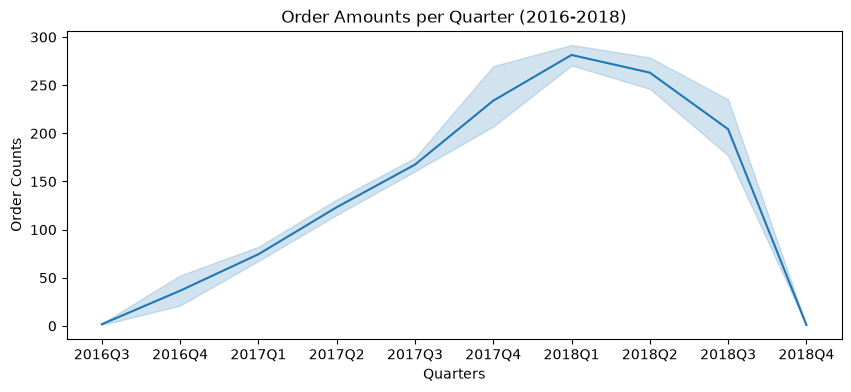

In [170]:


purchases_timeline = olist_df["order_purchase_timestamp"].value_counts().sort_index().reset_index()
purchases_timeline.columns = ["purchase_date", "counts"]

purchases_timeline["purchase_date"] = pd.to_datetime(purchases_timeline["purchase_date"])

purchases_timeline["quarter"] = purchases_timeline["purchase_date"].dt.to_period("Q")


purchases_per_quarter = purchases_timeline.groupby("quarter")["counts"].sum().reset_index()

purchases_timeline["quarter"] = purchases_timeline["quarter"].astype(str)

plt.figure(figsize= (10,4))
sns.lineplot(data = purchases_timeline, x = "quarter", y = "counts")


plt.title("Order Amounts per Quarter (2016-2018)")
plt.xlabel("Quarters")
plt.ylabel("Order Counts")

plt.show()

delivery delays

In [175]:


olist_df["order_estimated_delivery_date"] = pd.to_datetime(olist_df["order_estimated_delivery_date"])
olist_df["order_delivered_customer_date"] = pd.to_datetime(olist_df["order_delivered_customer_date"])

olist_df["dates_diff"] = (olist_df["order_delivered_customer_date"] - olist_df["order_estimated_delivery_date"]).dt.days

olist_df["dates_diff"]

0        -11.0
1         -8.0
2          1.0
3        -13.0
4         -6.0
          ... 
119138   -12.0
119139    -9.0
119140     7.0
119141   -19.0
119142   -13.0
Name: dates_diff, Length: 119143, dtype: float64

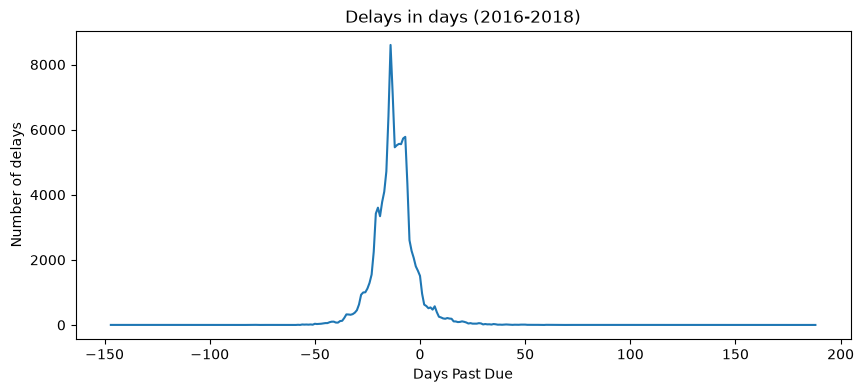

In [176]:

delay_counts = olist_df["dates_diff"].value_counts().sort_index().reset_index()
delay_counts.columns = ["Days Past Due", "Number of delays"]

plt.figure(figsize= (10,4))
sns.lineplot(data = delay_counts, x = "Days Past Due", y = "Number of delays")


plt.title("Delays in days (2016-2018)")
plt.xlabel("Days Past Due")
plt.ylabel("Number of delays")

plt.show()


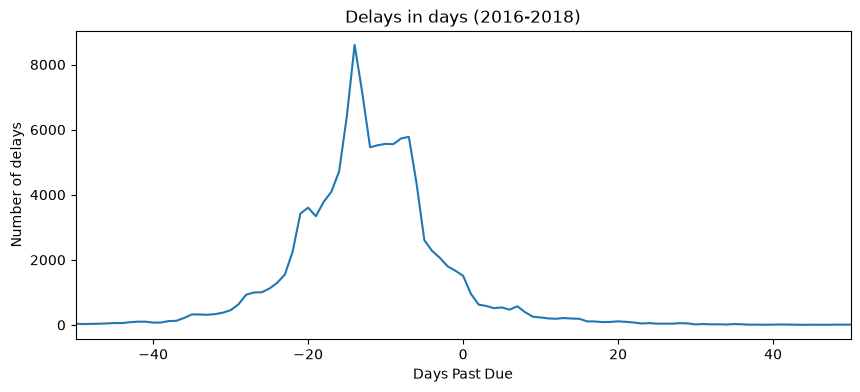

In [177]:
plt.figure(figsize= (10,4))
sns.lineplot(data = delay_counts, x = "Days Past Due", y = "Number of delays")

plt.xlim(left =-50, right = 50)
plt.title("Delays in days (2016-2018)")
plt.xlabel("Days Past Due")
plt.ylabel("Number of delays")

plt.show()

Purchase by product category

In [113]:
product_categories_map = {
    # --- ELECTRONICS ---
    "computers_accessories": "electronics",
    "telephony": "electronics",
    "tablets_printing_image": "electronics",
    "fixed_telephony": "electronics",
    "audio": "electronics",
    "air_conditioning": "electronics",
    "electronics": "electronics",
    "computers": "electronics",
    "cine_photo": "electronics",
    
    # --- HOUSEHOLD ---
    "bed_bath_table": "household",
    "furniture_decor": "household",
    "housewares": "household",
    "small_appliances": "household",
    "kitchen_dining_laundry_garden_furniture": "household",
    "home_appliances": "household",
    "home_confort": "household",
    "furniture_mattress_and_upholstery": "household",
    "furniture_living_room": "household",
    "furniture_bedroom": "household",
    "home_appliances_2": "household",
    "la_cuisine": "household",
    "home_comfort_2": "household",
    "small_appliances_home_oven_and_coffee": "household",
    
    # --- CONSTRUCTION ---
    "construction_tools_construction": "construction",
    "costruction_tools_garden": "construction",
    "home_construction": "construction",
    "construction_tools_lights": "construction",
    "construction_tools_safety": "construction",
    
    # --- BABIES ---
    "baby": "babies",
    "diapers_and_hygiene": "babies",
    "fashion_childrens_clothes": "babies",
    
    # --- OFFICE ---
    "stationery": "office",
    "office_furniture": "office",
    
    # --- ENTERTAINMENT ---
    "toys": "entertainment",
    "consoles_games": "entertainment",
    "cool_stuff": "entertainment", # Often miscellaneous trend/novelty items
    "party_supplies": "entertainment",
    "musical_instruments": "entertainment",
    "art": "entertainment",
    "christmas_supplies": "entertainment",
    
    # --- BEAUTY ---
    "health_beauty": "beauty",
    "perfumery": "beauty",
    "watches_gifts": "beauty", # Frequently grouped with personal styling/accessories
    
    # --- FASHION & ACCESSORIES ---
    # Comment: Added to group wearable items and luggage distinct from general beauty or household goods.
    "fashion_bags_accessories": "fashion",
    "fashion_shoes": "fashion",
    "luggage_accessories": "fashion",
    "fashion_male_clothing": "fashion",
    "fashion_underwear_beach": "fashion",
    "fashion_sport": "fashion",
    "fashio_female_clothing": "fashion",
    
    # --- AUTOMOTIVE ---
    # Comment: Added because automotive parts and tools do not fit standard household or electronics definitions.
    "auto": "automotive",
    
    # --- SPORTS & LEISURE ---
    # Comment: Added for outdoor activities, fitness gear, and hobbies that aren't strictly digital entertainment.
    "sports_leisure": "sports_leisure",
    
    # --- FOOD & BEVERAGE ---
    # Comment: Added because consumables (food, drinks) require different handling and classification than hard goods.
    "food_drink": "food_drink",
    "food": "food_drink",
    "drinks": "food_drink",
    
    # --- PETS ---
    # Comment: Added because pet supplies are a distinct retail vertical separate from human household or baby items.
    "pet_shop": "pet_shop",
    
    # --- BOOKS & MEDIA ---
    # Comment: Added to separate physical/digital reading materials and recorded media from toys and active entertainment.
    "books_technical": "books_media",
    "books_general_interest": "books_media",
    "books_imported": "books_media",
    "music": "books_media",
    "cds_dvds_musicals": "books_media",
    "dvds_blu_ray": "books_media",
    
    # --- COMMERCIAL & INDUSTRIAL ---
    # Comment: Added for B2B, agricultural, wholesale, or heavy professional categories.
    "market_place": "commercial_industrial",
    "costruction_tools_tools": "commercial_industrial", # Heavy professional tools
    "agro_industry_and_commerce": "commercial_industrial",
    "industry_commerce_and_business": "commercial_industrial",
    "signaling_and_security": "commercial_industrial",
    "security_and_services": "commercial_industrial",
    
    # --- MISCELLANEOUS ---
    # Comment: Added for specific items that span multiple categories (e.g., household decor vs. agriculture).
    "garden_tools": "miscellaneous",
    "flowers": "miscellaneous",
    "arts_and_craftmanship": "miscellaneous"
}

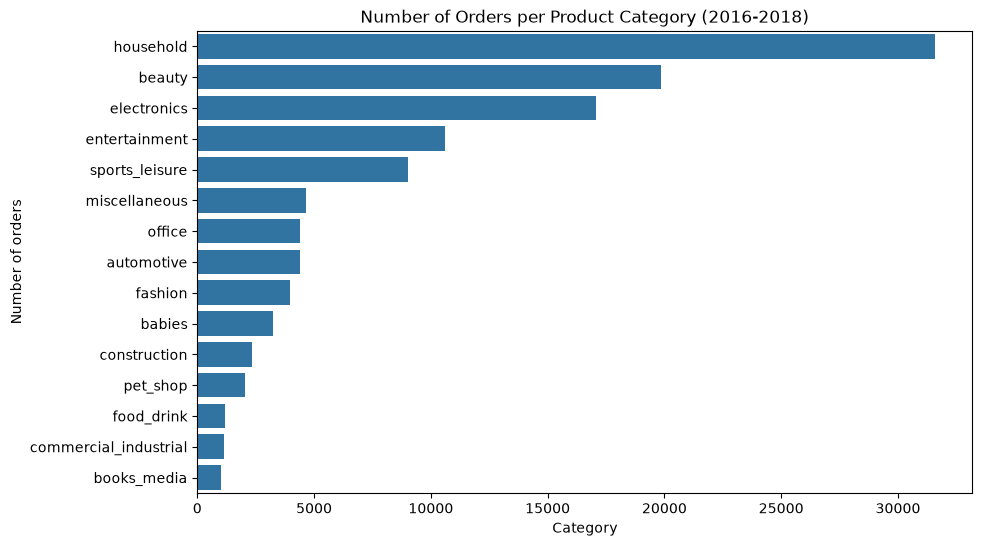

In [ ]:
olist_df["product_cat"] = olist_df.product_category_name_english.map(product_categories_map)
order_num_per_cat = olist_df["product_cat"].value_counts().sort_values(ascending= False).reset_index()

order_num_per_cat.columns = ["Category", "Number of orders"]

plt.figure(figsize= (10,6))
sns.barplot(data = order_num_per_cat, x = "Number of orders", y = "Category")


plt.title("Number of Orders per Product Category (2016-2018)")
plt.xlabel("Number of orders")
plt.ylabel("Category")

plt.show()


Map

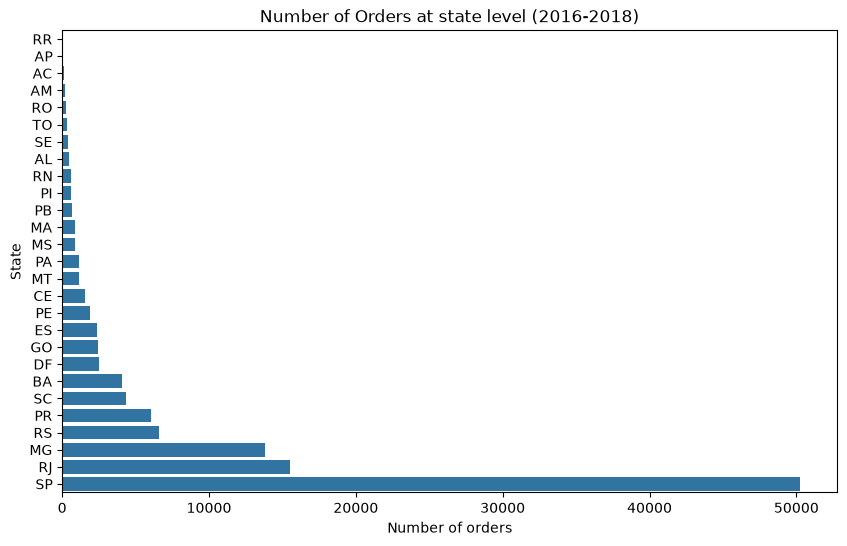

In [182]:


Order_num_state = olist_df["customer_state"].value_counts().sort_values().reset_index()

plt.figure(figsize= (10,6))
sns.barplot(data = Order_num_state, x = "count", y = "customer_state")


plt.title("Number of Orders at state level (2016-2018)")
plt.xlabel("Number of orders")
plt.ylabel("State")

plt.show()
